# Machine Learning Piplines and GridSearchCV

In this lab we will:
- Generate synthetic data for running targeted experiments using scikit-learn
- Train and evaluate a KNN classification model using a pipeline
- Tune model hyperparameters using a pipeline within a cross-validation grid search
- Build a more complex random forest classification pipeline using real-world data
- Extract the feature importances from the trained pipeline

### Import the required libraries

In [1]:
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3
!pip install -q seaborn==0.13.2

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Train a model using a pipline

In [3]:
# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target
labels = data.target_names

### Instantiate a pipline consists of StandardScaler, PCA, and KNeighborsClassifier

In [4]:
pipeline = Pipeline ([
    ('scaler', StandardScaler()), # Step 1: Standardize features
    ('pca', PCA(n_components=2),), # Step 2: Reduce dimensions to 2 using DCA
    ('knn', KNeighborsClassifier(n_neighbors=5,)) # Step 3: K-Nearest Neighbors classifier
])

### Split the data into training and test sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

### Fit the pipeline on the training set

In [6]:
pipeline.fit(X_train, y_train)

# Measure the pipline accuracy on the test data
test_score = pipeline.score(X_test, y_test)
print(f"{test_score:.3f}")

0.900


### Get the model predictions

In [7]:
y_pred = pipeline.predict(X_test)

### Generate the confusion matrix for the KNN model and plot it

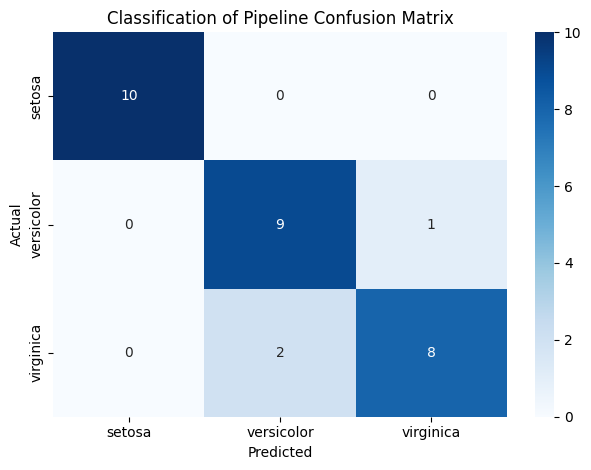

In [8]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

# Set the title and labels
plt.title("Classification of Pipeline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

- The model incorrectly classified 2 virginica as versicolor, 1 versicolor as virginica.

### Tune hyperparameters using a pipeline within cross-validation grid search

In [9]:
# Instantiate the pipeline
pipeline = Pipeline (
                     [('scaler', StandardScaler()),
                      ('pca', PCA()),
                      ('knn', KNeighborsClassifier())
                     ]
                    )

### Define a model parameter grid to search over

In [14]:
# Hyperparameter search grid for numbers of PCA components and KNN neigbors
param_grid = {'pca__n_components': [2, 3],
              'knn__n_neighbors': [3, 5, 7]
              }

### Choose a cross validation method

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Determine the best parameters

In [16]:
best_model = GridSearchCV(estimator = pipeline,
                          param_grid = param_grid,
                          cv = cv,
                          scoring = 'accuracy',
                          verbose = 2
                        )

### Fit the best `GridSearchCV` model to the training data

In [17]:
best_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=2)

### Evaluate the accuracy of the best model on the test set

In [20]:
test_score = best_model.score(X_test, y_test)
print(f"{test_score:.3f}")

0.933


### Display the best parameters

In [21]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}

### Plot the confusion matrix for the predictions on the test set

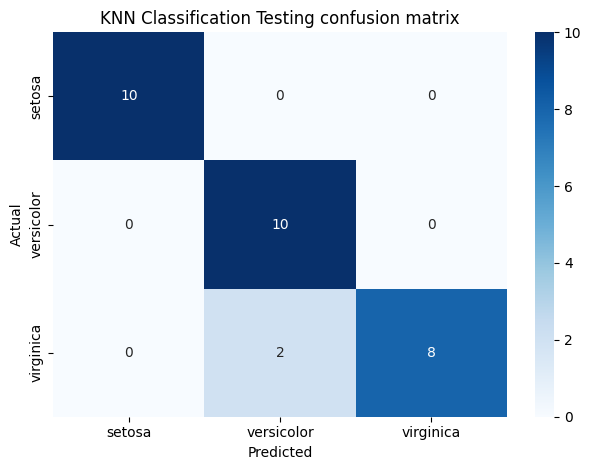

In [23]:
y_pred = best_model.predict(X_test)

# Generate the confusion matrix for KNN
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)

plt.title("KNN Classification Testing confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()